# NIRISS GR150C Grism Simulation

Simulate 100 random 2D Gaussian sources (FWHM = 1.6 pix) on the NIRISS detector,
each with a spectral shape drawn from the pystellibs Kurucz library, dispersed
through **GR150C** in three filters: **F115W, F150W, F200W**. The same sources
(positions, amplitudes, spectra) are used in all three filters.

Uses the `simulate()` wrapper from `simulate.py` — traces from the CRDS specwcs
references via grismagic, weighted by the first-order sensitivity curves.
Outputs (direct + grism FITS per filter, truth catalog ECSV) are written to `output/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from simulate import simulate

In [29]:
FILTERS = ('F115W', 'F150W', 'F200W')

results, catalog = simulate(
    n_sources=1000,
    seed=47,
    filters=FILTERS,
    orders=('+1',),
    fwhm=1.6,
    amp_range=(0.01, 100.0)
)

print(f"Simulated {len(catalog)} sources in {len(FILTERS)} filters; outputs in output/")

100%|██████████| 1178/1178 [00:02<00:00, 433.63it/s]


Simulated 1000 sources in 3 filters; outputs in output/


## Truth catalog

Positions, amplitudes, Kurucz stellar parameters and per-filter fluxes
(`flux_<filt>` = total counts in the direct image = expected counts in the +1 spectrum).

In [30]:
catalog[:10]

id,x,y,amplitude,fwhm_pix,kurucz_index,teff,logg,Z,logz,flux_F115W,flux_F150W,flux_F200W
int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64
0,1470.850086099452,1577.6959775748878,96.83170653262015,1.6,3018,18000.000000000015,3.5,0.00632455525919795,-0.5,1.411960521318618e+22,8.496389952744138e+21,4.0025963187955045e+21
1,1492.7799740370353,1062.1887425312316,81.74695809529344,1.6,900,26999.999999999975,4.5,0.019999999552965164,0.0,1.1260938254023542e+22,6.565797461041097e+21,2.980145794693721e+21
2,959.6536346480855,1654.0240177093472,29.080021677910107,1.6,1292,37000.0,5.0,0.0006324555142782629,-1.5,3.891900477774709e+21,2.2422042779285775e+21,1.0049895385349061e+21
3,291.6838547893044,235.96831650324665,88.63744730816697,1.6,2651,34000.00000000002,4.0,0.03169786557555199,0.2,1.1891858486102615e+22,6.838617234171926e+21,3.0618562872249213e+21
4,1886.742218477956,1804.5996326623892,63.25198489128497,1.6,2639,24000.00000000002,4.5,0.03169786557555199,0.2,8.822119237566202e+21,5.177834877389306e+21,2.3665338950594194e+21
5,692.7465929849113,199.6606533933509,20.98560906715449,1.6,2959,40999.99999999999,4.5,0.00632455525919795,-0.5,2.8069431994102506e+21,1.6162105957495375e+21,7.238108881040229e+20
6,470.21270665165173,1236.812943736426,11.128391410071226,1.6,2566,7749.999999999997,1.0,0.03169786557555199,0.2,1.9305332048694417e+21,1.27834726983783e+21,6.641930028622338e+20
7,1685.1389816288383,940.4784600664784,63.261725923744955,1.6,2445,10249.999999999996,3.5,0.03169786557555199,0.2,1.0206018503711255e+22,6.394128176664104e+21,3.1667202700802476e+21
8,1048.293975401985,1479.6041613941504,51.29283011973347,1.6,1591,4499.999999999998,3.5,6.324555579340085e-05,-2.5,1.0798614060977288e+22,1.1165456120997304e+22,7.18193804327528e+21


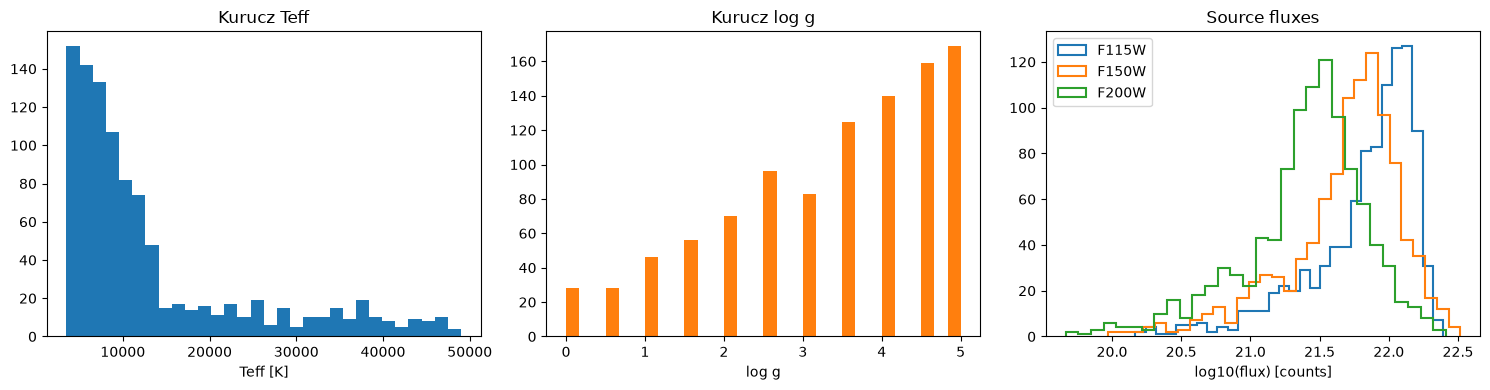

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(catalog['teff'], bins=30, color='C0')
axes[0].set_xlabel('Teff [K]'); axes[0].set_title('Kurucz Teff')
axes[1].hist(catalog['logg'], bins=30, color='C1')
axes[1].set_xlabel('log g'); axes[1].set_title('Kurucz log g')
for filt in FILTERS:
    axes[2].hist(np.log10(catalog[f'flux_{filt}']), bins=30, histtype='step', lw=1.5, label=filt)
axes[2].set_xlabel('log10(flux) [counts]'); axes[2].set_title('Source fluxes'); axes[2].legend()
plt.tight_layout()
plt.show()

## Direct images

16.859828848802028
16.981458453813488
16.866944174616638


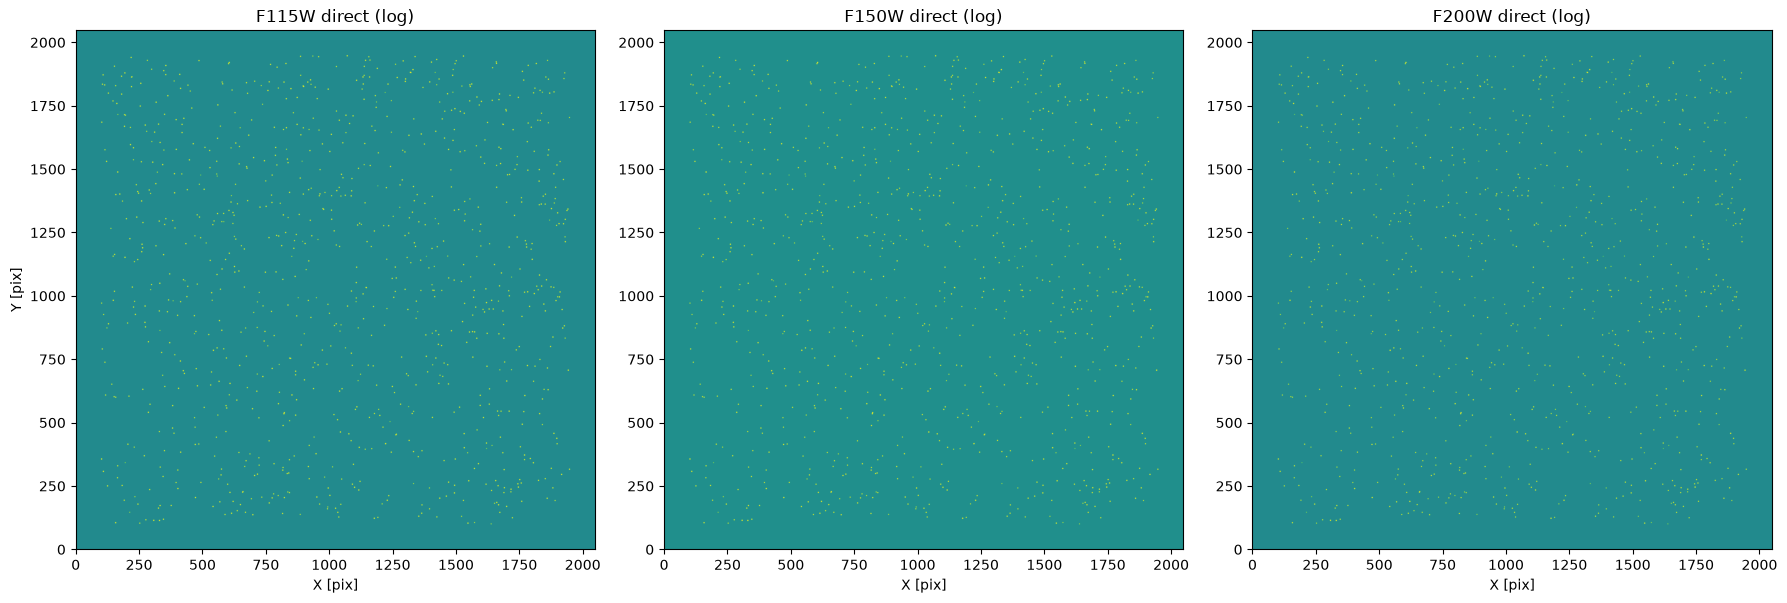

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, filt in zip(axes, FILTERS):
    img = results[filt]['direct']
    print(np.min(np.log10(img + img.max() * 1e-5)))
    ax.imshow(np.log10(img + img.max() * 1e-5), origin='lower', cmap='viridis', vmin=14, vmax=20)
    # ax.plot(catalog['x'], catalog['y'], 'r+', ms=6, mew=0.6, alpha=0.5)
    ax.set_title(f'{filt} direct (log)')
    ax.set_xlabel('X [pix]')
axes[0].set_ylabel('Y [pix]')
plt.tight_layout()
plt.show()

## Dispersed (grism) images

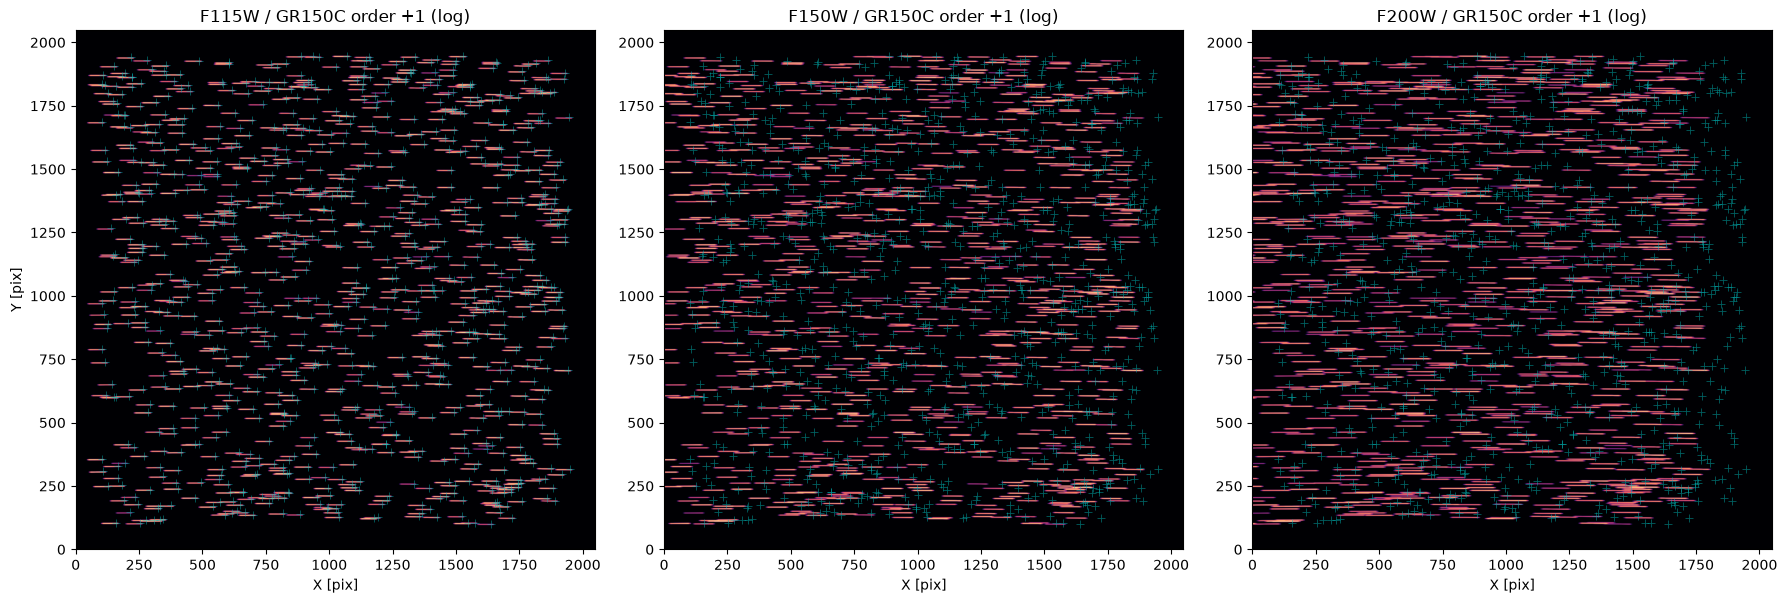

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, filt in zip(axes, FILTERS):
    img = results[filt]['dispersed']
    ax.imshow(np.log10(img + img.max() * 1e-5), origin='lower', cmap='magma')
    ax.plot(catalog['x'], catalog['y'], 'c+', ms=6, mew=0.6, alpha=0.5)
    ax.set_title(f'{filt} / GR150C order +1 (log)')
    ax.set_xlabel('X [pix]')
axes[0].set_ylabel('Y [pix]')
plt.tight_layout()
plt.show()

## Zoom on one source

Direct Gaussian and its three dispersed traces. GR150C disperses along X
(blueward offsets); each filter places the trace of the same source at a
different distance from its direct position.

Source 259: x=904.8, y=1206.6, Teff=7500 K, logg=4.50, amp=99.75


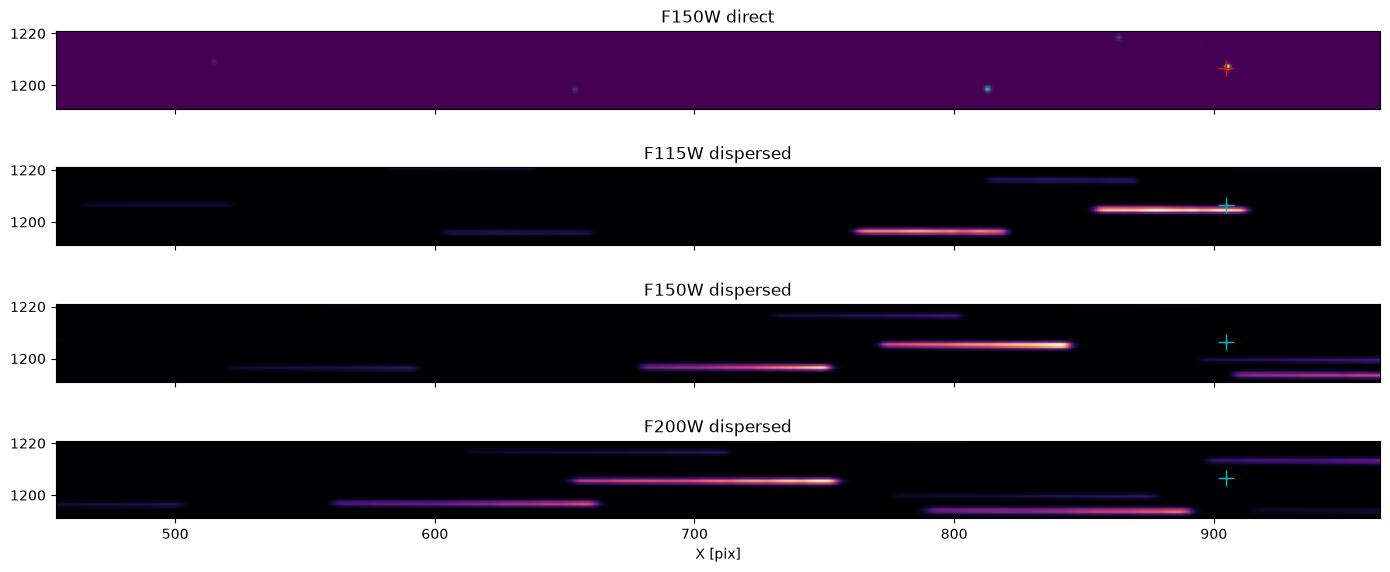

In [34]:
# pick a bright source near the middle of the detector
central = (np.abs(catalog['x'] - 1024) < 500) & (np.abs(catalog['y'] - 1024) < 500)
mid = np.argmax(catalog['amplitude'] * central)
xs, ys = catalog['x'][mid], catalog['y'][mid]
xc, yc = int(xs), int(ys)
print(f"Source {catalog['id'][mid]}: x={xs:.1f}, y={ys:.1f}, "
      f"Teff={catalog['teff'][mid]:.0f} K, logg={catalog['logg'][mid]:.2f}, "
      f"amp={catalog['amplitude'][mid]:.2f}")

fig, axes = plt.subplots(4, 1, figsize=(14, 6), sharex=True)
dimg = results['F150W']['direct']
axes[0].imshow(dimg[yc-15:yc+15, xc-450:xc+60], origin='lower', cmap='viridis',
               extent=[xc-450, xc+60, yc-15, yc+15], aspect='equal')
axes[0].plot(xs, ys, 'r+', ms=12)
axes[0].set_title('F150W direct')
for ax, filt in zip(axes[1:], FILTERS):
    img = results[filt]['dispersed']
    ax.imshow(img[yc-15:yc+15, xc-450:xc+60], origin='lower', cmap='magma',
              extent=[xc-450, xc+60, yc-15, yc+15], aspect='equal')
    ax.plot(xs, ys, 'c+', ms=12)
    ax.set_title(f'{filt} dispersed')
axes[-1].set_xlabel('X [pix]')
plt.tight_layout()
plt.show()

## Flux consistency check

In [35]:
for filt in FILTERS:
    F = np.asarray(catalog[f'flux_{filt}']).sum()
    d = results[filt]['dispersed'].sum()
    dr = results[filt]['direct'].sum()
    print(f"{filt}: dispersed/truth = {d/F:.4f}   direct/truth = {dr/F:.4f}"
          f"   (deficit = flux dispersed off the detector edge)")

F115W: dispersed/truth = 1.0000   direct/truth = 1.0000   (deficit = flux dispersed off the detector edge)
F150W: dispersed/truth = 0.9968   direct/truth = 1.0000   (deficit = flux dispersed off the detector edge)
F200W: dispersed/truth = 0.9534   direct/truth = 1.0000   (deficit = flux dispersed off the detector edge)
